In [36]:
import os
import csv

os.chdir('/Users/rv/Projects/7CS074') # Change to the project root directory

import pandas as pd
import numpy as np

from datetime import datetime
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.metrics import (
	silhouette_score
)

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import StandardScaler

In [37]:
BASE_DIR = os.getcwd()

DATA_RAW_PATH = os.path.join(BASE_DIR, "data/raw")
DATA_CLEAN_PATH = os.path.join(BASE_DIR, "data/clean")

DATASET_CLEAN_FILE_PATH = os.path.join(DATA_CLEAN_PATH, "cleaned_dataset.csv")

COLUMNS = [
    "make",
    "model",
    "year",
    "price",
    "transmission",
    "mileage",
    "fuelType",
    "tax",
    "mpg",
    "engineSize",
]

NUMERIC_OUTLIER_COLUMNS = [
    "price",
    "mileage",
    "mpg",
    "engineSize",
    "tax"
]

# columns needed as input for FeatureEngineer to do calculations and engineer new useful numeric features
CLUSTERING_RAW_INPUT = [
    'price',
    'mileage',
    'mpg',
    'engineSize',
    'year',
    'tax'
]

# final feature set after engineering (used for model fitting)
CLUSTERING_NUMERIC_FEATURES = [
    'mileage',
    'tax',
    'efficiency_score',
    'vehicle_age'
]

EXTRA_COLUMNS = ['mileage2', 'fuel type2', 'engine size2', 'reference']
EXPECTED_COLUMNS = 9

In [38]:
def calculate_silhouette_score(X, labels):
    """Calculate silhouette score for clustering"""
    mask = labels != -1
    unique_labels = len(set(labels[mask]))
    if unique_labels < 2:  # Need at least 2 clusters
        return None
    
    try:
        return silhouette_score(X[mask], labels[mask])
    except:
        return None
    
def assign_cluster_labels(df: pd.DataFrame, cluster_col: str = 'cluster') -> pd.DataFrame:
    """
    Assigns meaningful labels to clusters based on car characteristics.
    
    Labels:
    - 'Luxury': High price, low mileage, premium features
    - 'Performance': High engine size, moderate-high price
    - 'Efficient': High MPG, smaller engine size
    - 'Family SUV': Moderate price, good MPG, practical
    - 'Budget': Low price, higher mileage
    - 'Electric/Hybrid': Electric or Hybrid fuel type
    """
    df = df.copy()
    
    # Calculate cluster statistics
    cluster_stats = df.groupby(cluster_col).agg({
        'price': 'mean',
        'mileage': 'mean',
        'mpg': 'mean',
        'engineSize': 'mean',
        'fuelType': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
    }).reset_index()
    
    # Create label mapping
    label_map = {}
    
    price_high = cluster_stats['price'].quantile(0.67)
    price_low  = cluster_stats['price'].quantile(0.33)
    mileage_low = cluster_stats['mileage'].quantile(0.33)
    mileage_high = cluster_stats['mileage'].quantile(0.67)
    engine_high = cluster_stats['engineSize'].quantile(0.67)
    
    for _, row in cluster_stats.iterrows():
        cluster_id = row[cluster_col]

        # Check for Electric/Hybrid first
        if row['fuelType'] in ['Electric', 'Hybrid']:
            label_map[cluster_id] = 'Electric/Hybrid'
        # Luxury: high price, low mileage
        elif row['price'] > price_high and row['mileage'] < mileage_low:
            label_map[cluster_id] = 'Luxury'
        # Performance: large engine, high price
        elif row['engineSize'] > engine_high and row['price'] > df['price'].median():
            label_map[cluster_id] = 'Performance'
        # Efficient: high MPG, smaller engine
        elif row['mpg'] > mileage_high and row['engineSize'] < df['engineSize'].median():
            label_map[cluster_id] = 'Efficient'
        # Budget: low price, high mileage
        elif row['price'] < price_low:
            label_map[cluster_id] = 'Budget'
        # Family SUV: everything else (moderate across board)
        else:
            label_map[cluster_id] = 'Family SUV'
    
    df['cluster_label'] = df[cluster_col].map(label_map)
    
    return df, label_map

In [39]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
        Helps with the pipeline to engineer any other features before any training (preprocessed)
        
        - Creates efficiency score to remove the stress on training on two features (mpg and engine size) to determine price, instead just create efficiency score to let model decide on that.
        - Creates vehicle age to better determine the age of vehicle instead of year of manufacture.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if {'mpg', 'engineSize'}.issubset(X.columns):

            X['efficiency_score'] = np.where(
                X['engineSize'] > 0,
                X['mpg'] / X['engineSize'],
                np.nan
            )

        if {'year'}.issubset(X.columns):

            current_year = datetime.now().year

            X['vehicle_age'] = current_year - X['year']

        return X

In [40]:
# First we will check and run the preprocessing script
# In case this is already done, this will not overwrite existing files
def process_raw_multiple_data_files():
    if not os.path.exists(DATA_RAW_PATH):
        raise FileNotFoundError("Data directory not found. Please ensure the project structure is correct.")

    # Creates if not exists
    if not os.path.exists(DATA_CLEAN_PATH):
        os.makedirs(DATA_CLEAN_PATH)

    if os.path.exists(DATASET_CLEAN_FILE_PATH):
        return  # If cleaned dataset already exists, skip processing

    # Creates if not exists, double check at this point
    if not os.path.exists(DATASET_CLEAN_FILE_PATH):
        os.makedirs(DATA_CLEAN_PATH, exist_ok=True)

    directory_raw_bytes = os.fsencode(DATA_RAW_PATH)

    # Validate that CSV files to see if exists and is non-empty
    for file in os.listdir(directory_raw_bytes):
        filename = os.fsdecode(file)
        if filename.endswith(".csv"):
            DATASET_PATH = os.path.join(DATA_RAW_PATH, filename)
            df = pd.read_csv(DATASET_PATH)
            if df.empty:
                raise ValueError("Loaded dataset is empty. Please check the dataset file.")
            continue
        else:
            continue

    # Concatenate all CSV files in the raw data directory
    # We will read the clean path / file directly, and add the default headers
    # We will use our COLUMNS variable as the schema
    schema = COLUMNS
    with open(DATASET_CLEAN_FILE_PATH, 'w') as csvfile:
        writer = csv.writer(csvfile, delimiter=',')
        writer.writerow([g for g in schema])

    for file in os.listdir(directory_raw_bytes):
        filename = os.fsdecode(file)
        if filename.endswith(".csv"):
            DATASET_PATH = os.path.join(DATA_RAW_PATH, filename)
            df_default = pd.read_csv(DATASET_PATH)
            df = clean_data(df_default)

            if not df.empty:
                make = filename.replace('.csv', '')
                df.insert(0, 'make', make) # Insert 'make' as first column
                
                # Only keep rows with exactly EXPECTED_COLUMNS + 1 columns after inserting 'make'
                df = df[df.apply(lambda x: len(x) == EXPECTED_COLUMNS + 1, axis=1)]

                df.to_csv(
                    DATASET_CLEAN_FILE_PATH,
                    mode='a',
                    header=False,
                    index=False
                )
        else:
            continue

def remove_iqr_outliers(
    df: pd.DataFrame,
    columns: list,
    factor: float = 1.5
) -> pd.DataFrame:
    """
        Remove outliers using Interquartile Range (IQR) method for selected columns.
    """
    df = df.copy()

    for col in columns:
        if col not in df.columns:
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

def apply_domain_constraints(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
        Apply domain constraints to the dataframe, meaning that we filter the data based on known valid ranges for each numeric column, so that we remove any rows that have values outside these ranges.
    """
    df = df.copy()

    constraints = {
        'price': lambda x: (x > 100) & (x < 200_000),
        'mileage': lambda x: (x >= 0) & (x < 300_000),
        'engineSize': lambda x: (x > 0) & (x < 12.0),
        'mpg': lambda x: (x > 5) & (x < 60),
        'tax': lambda x: (x >= 0)
    }

    for col, condition in constraints.items():
        if col in df.columns:
            df = df[condition(df[col])]

    return df

def coerce_numeric_columns(
    df: pd.DataFrame, 
    columns: list
) -> pd.DataFrame:
    """
        Here we make sure that any columns parse we parse to integers / numeric values, if record in column is string of currency numeric, we remove this regex
    """
    df = df.copy()

    for col in columns:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(r"[£,]", "", regex=True)
                .str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

# Cleans the data, and returns copy of cleaned dataframe
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
        Here we clean out the data from any possible problems which can cause bad training
    """
    df = df.copy()
    
    # Remove extra columns and duplicate columns if present
    df.drop(columns=[col for col in EXTRA_COLUMNS if col in df.columns], inplace=True, errors='ignore')
    df = df.loc[:, ~df.columns.duplicated()]
    
    # Only keep rows with exactly EXPECTED_COLUMNS columns
    df = df[df.apply(lambda x: len(x) == EXPECTED_COLUMNS, axis=1)]
    
    # Replace 'N/A' and Drop record duplicates
    # If by any chance 'N/A' is a string by text, we shall change it to nan 'na', later we will remove anyway
    df.replace("N/A", np.nan, inplace=True)
    df.drop_duplicates(inplace=True)

    # Drop rows that are all empty or just commas 
    # """
    #     ,,,,,,,,,,
    # """
    df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
    df.dropna(how='all', inplace=True)

    # Coerce numeric columns
    df = coerce_numeric_columns(df, NUMERIC_OUTLIER_COLUMNS)
    # Domain filtering
    df = apply_domain_constraints(df)
    # Statistical outliers
    df = remove_iqr_outliers(
        df,
        columns=[c for c in NUMERIC_OUTLIER_COLUMNS if c in df.columns]
    )
    
    return df

process_raw_multiple_data_files()

In [41]:
if not os.path.exists(DATASET_CLEAN_FILE_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_CLEAN_FILE_PATH}. Please ensure the dataset is placed correctly.")

df = pd.read_csv(DATASET_CLEAN_FILE_PATH, sep=',', engine='python') # read with proper delimiter handling, and with python engine always
if df.empty:
    raise ValueError("Loaded dataset is empty. Please check the dataset file.")

print(f"Data loaded successfully from {DATASET_CLEAN_FILE_PATH}.")

Data loaded successfully from /Users/rv/Projects/7CS074/data/clean/cleaned_dataset.csv.


In [42]:
pipeline = Pipeline(steps=[
    ("feature_engineering", FeatureEngineer()),
    ("scaler", StandardScaler())
])

X_copy = df[CLUSTERING_RAW_INPUT].copy()
X_transformed = pipeline.fit_transform(X_copy)

# fit_transform returns a numpy array, convert back to DataFrame and add price back to assign the correct labels
X_transformed = pd.DataFrame(
    X_transformed, 
    columns=CLUSTERING_RAW_INPUT + ['efficiency_score', 'vehicle_age']
)

X = X_transformed[CLUSTERING_NUMERIC_FEATURES].values

random_state = 42
silhouette_scores = {}
clustering_results = {}

In [43]:
print("Finding optimal number of clusters...")

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=random_state)
    labels = km.fit_predict(X)
    silhouette_scores[k] = silhouette_score(X, labels)
    print(f"  k={k}: Silhouette Score: {silhouette_scores[k]:.3f}")

optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal k: {optimal_k} (Score: {silhouette_scores[optimal_k]:.3f})")

model = KMeans(n_clusters=optimal_k, random_state=random_state)

Finding optimal number of clusters...
  k=2: Silhouette Score: 0.364
  k=3: Silhouette Score: 0.415
  k=4: Silhouette Score: 0.439
  k=5: Silhouette Score: 0.441
  k=6: Silhouette Score: 0.305
  k=7: Silhouette Score: 0.313
  k=8: Silhouette Score: 0.309
  k=9: Silhouette Score: 0.307

Optimal k: 5 (Score: 0.441)


In [44]:
# Fit the model
labels = model.fit_predict(X)

# Add cluster labels to dataframe
df_clustered = df.copy()
df_clustered['cluster'] = labels

# Assign meaningful labels
df_clustered, label_map = assign_cluster_labels(df_clustered, 'cluster')

unique_labels = len(set(labels))
if unique_labels > 1:
	silhouette = calculate_silhouette_score(X, labels)
else:
	silhouette = None

clustering_results = {
	'model': model,
	'labels': labels,
	'df_clustered': df_clustered,
	'label_map': label_map,
	'silhouette_score': silhouette,
	'features': CLUSTERING_NUMERIC_FEATURES,
	'n_clusters': unique_labels
}

In [45]:

print(f"Number of clusters: {clustering_results['n_clusters']}")
if clustering_results['silhouette_score'] is not None:
    print(f"Silhouette Score: {clustering_results['silhouette_score']:.3f}")
else:
    print(f"Silhouette Score: Not available")

print(f"\nCluster Distribution:")
if 'cluster_label' in clustering_results['df_clustered'].columns:
    distribution = clustering_results['df_clustered']['cluster_label'].value_counts()
    for label, count in distribution.items():
        print(f"  {label}: {count} cars")

Number of clusters: 5
Silhouette Score: 0.441

Cluster Distribution:
  Luxury: 17291 cars
  Family SUV: 14751 cars
  Budget: 2220 cars


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

def plot_clusters(df: pd.DataFrame, cluster_col: str = 'cluster_label',  x_col: str = 'mpg', y_col: str = 'price',  title: str = "Car Clusters"):
    """Scatter plot of clusters with labels"""
    plt.figure(figsize=(12, 8))
    
    # Use cluster_label if available, otherwise use cluster
    label_col = cluster_col if cluster_col in df.columns else 'cluster'
    
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=label_col,
        palette='Set2',
        s=100,
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5
    )
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(x_col.upper() if len(x_col) <= 3 else x_col.title(), fontsize=12)
    plt.ylabel(y_col.title(), fontsize=12)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

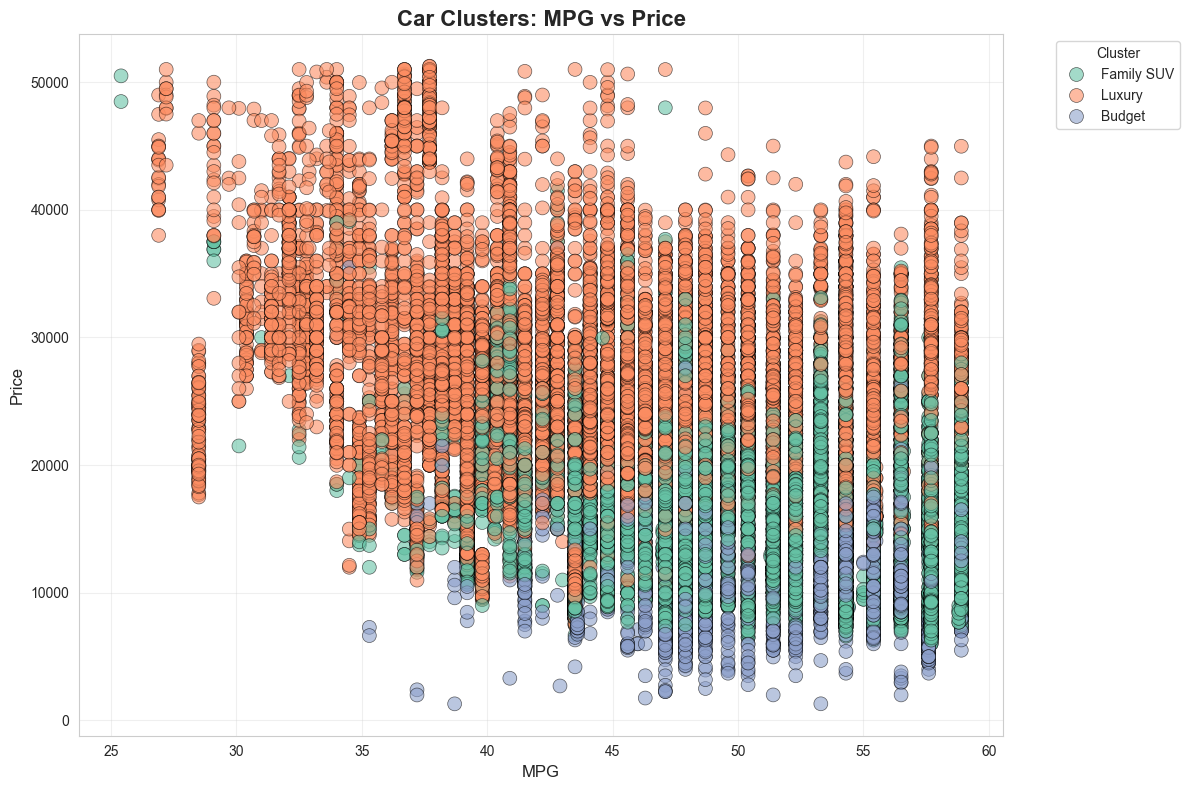

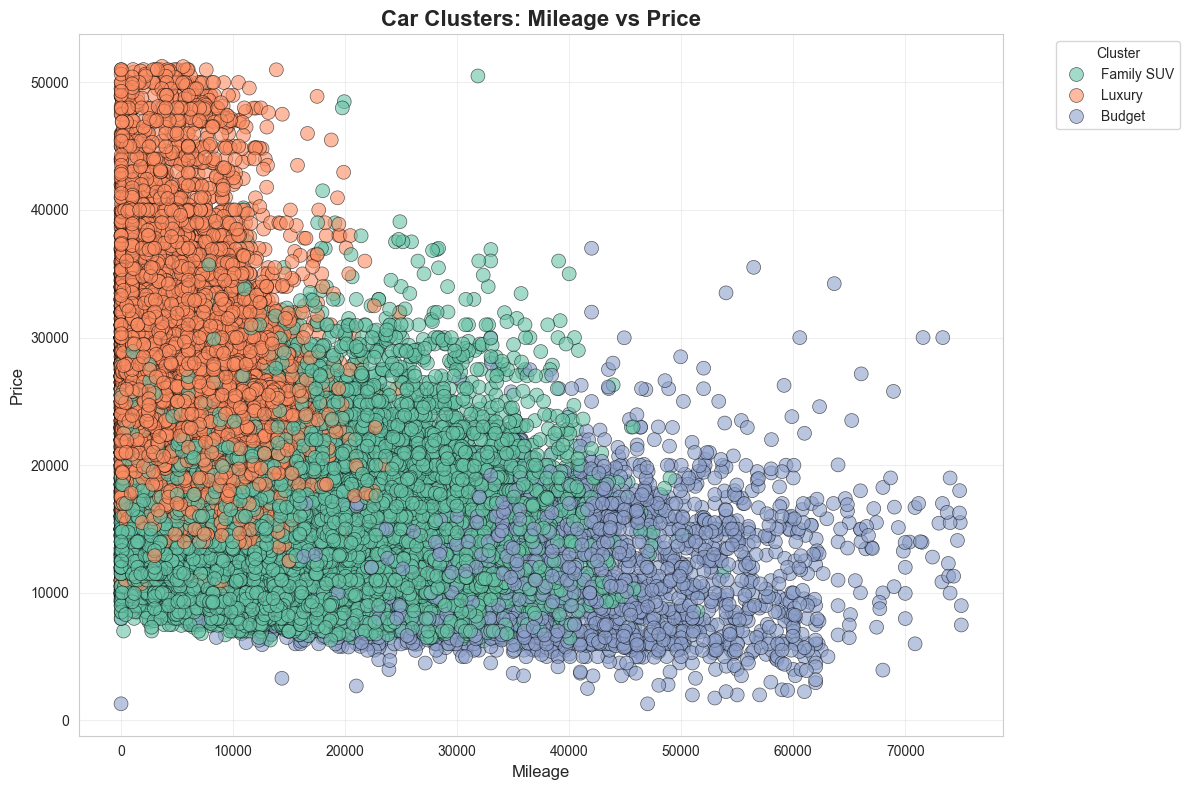

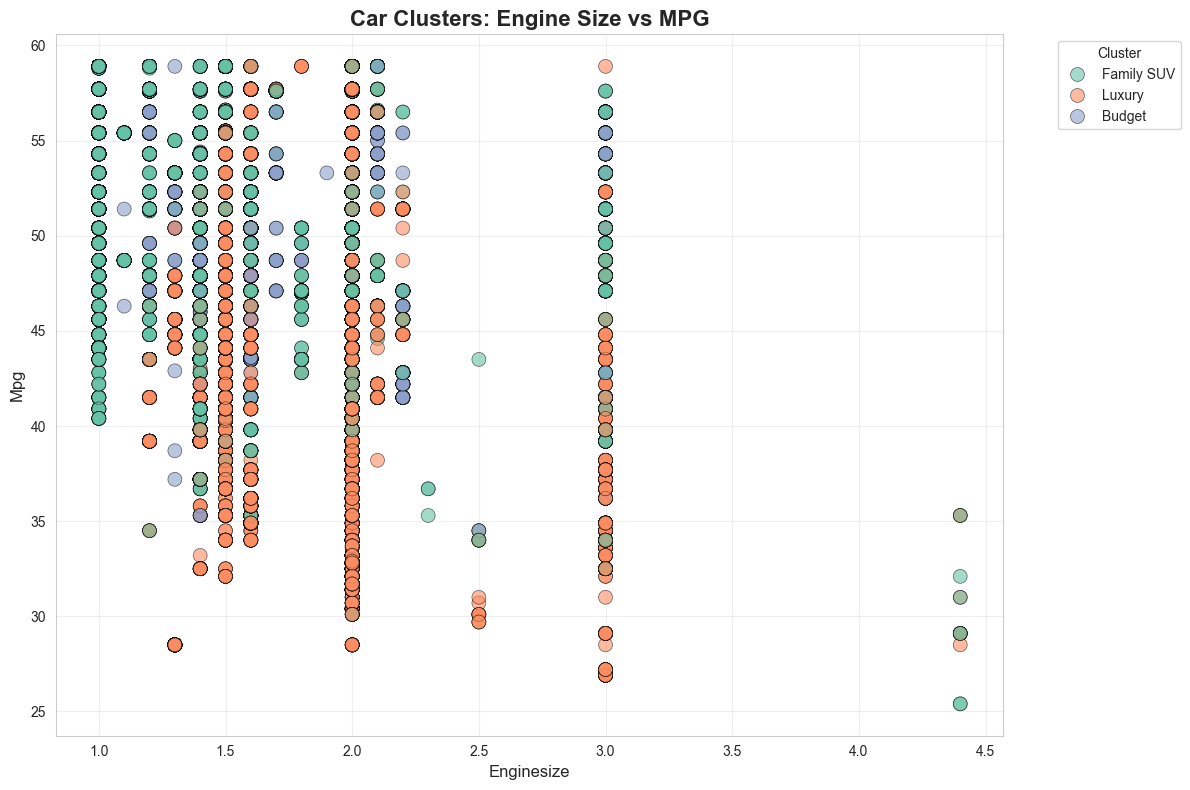

In [47]:
# Compare clustering algorithms
df_clustered = clustering_results['df_clustered']

# Cluster scatter plots with different feature combinations
plot_clusters(
    df_clustered, 
    cluster_col='cluster_label',
    x_col='mpg', 
    y_col='price',
    title='Car Clusters: MPG vs Price'
)

plot_clusters(
    df_clustered,
    cluster_col='cluster_label',
    x_col='mileage',
    y_col='price',
    title='Car Clusters: Mileage vs Price'
)

plot_clusters(
    df_clustered,
    cluster_col='cluster_label',
    x_col='engineSize',
    y_col='mpg',
    title='Car Clusters: Engine Size vs MPG'
)
